# Exploratory Data Analysis
### Author: Ariel Cintrón-Arias

### Required Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Data Dictionary
```
dataset:
  name: fetch_diabetes_hospital
  source: 130-US Hospitals Diabetes Dataset (1999–2008)
  dimensions:
    total_rows: 101766
    total_columns: 25
    features_count: 24
    target_count: 1
  columns:
    - name: race
      type: Categorical
      role: Feature (Sensitive)
      description: Race of the patient
      valid_values: [African American, Asian, Caucasian, Hispanic, Other, Unknown]
    - name: gender
      type: Categorical
      role: Feature (Sensitive)
      description: Gender of the patient
      valid_values: [Female, Male]
    - name: age
      type: Categorical
      role: Feature (Sensitive)
      description: Grouped age brackets
      valid_values: ['30 years or younger', '30-60 years', 'Over 60 years']
    - name: admission_source_id
      type: Categorical
      role: Feature
      description: Entry point to the hospital
      valid_values: [Emergency, Referral, Other]
    - name: discharge_disposition_id
      type: Categorical
      role: Feature
      description: Release destination after hospital stay
      valid_values: [Discharged to Home, Other]
    - name: medical_specialty
      type: Categorical
      role: Feature
      description: Specialty of the admitting physician
      valid_values: [Cardiology, Internal Medicine, Emergency, Family/General Practice, Missing, Other]
    - name: time_in_hospital
      type: Integer
      role: Feature
      description: Number of days spent in hospital
      valid_values: 1-14
    - name: num_lab_procedures
      type: Integer
      role: Feature
      description: Number of lab tests performed during visit
    - name: num_procedures
      type: Integer
      role: Feature
      description: Number of non-lab procedures performed during visit
    - name: num_medications
      type: Integer
      role: Feature
      description: Number of unique generic medications administered
    - name: primary_diagnosis
      type: Categorical
      role: Feature
      description: Grouped primary diagnosis code
      valid_values: [Diabetes, Genitourinary, Musculoskeletal, Respiratory, Other]
    - name: number_diagnoses
      type: Integer
      role: Feature
      description: Total number of diagnoses entered into the system
    - name: max_glu_serum
      type: Categorical
      role: Feature
      description: Glucose serum test results
      valid_values: [None, Norm, ">200", ">300"]
    - name: A1Cresult
      type: Categorical
      role: Feature
      description: Hemoglobin A1c test results
      valid_values: [None, Norm, ">7", ">8"]
    - name: insulin
      type: Categorical
      role: Feature
      description: Status of insulin prescription
      valid_values: [No, Down, Steady, Up]
    - name: change
      type: Binary
      role: Feature
      description: Indicates if there was a change in diabetic medications
      valid_values: [No, Ch]
    - name: diabetesMed
      type: Binary
      role: Feature
      description: Was any diabetic medication prescribed?
      valid_values: [True, False]
    - name: medicare
      type: Binary
      role: Feature
      description: Patient has Medicare coverage
      valid_values: [True, False]
    - name: medicaid
      type: Binary
      role: Feature
      description: Patient has Medicaid coverage
      valid_values: [True, False]
    - name: had_emergency
      type: Binary
      role: Feature
      description: Patient had emergency room visits in the prior year
      valid_values: [True, False]
    - name: had_inpatient_days
      type: Binary
      role: Feature
      description: Patient had hospital inpatient days in the prior year
      valid_values: [True, False]
    - name: had_outpatient_days
      type: Binary
      role: Feature
      description: Patient had outpatient clinic visits in the prior year
      valid_values: [True, False]
    - name: readmit_30_days
      type: Binary
      role: Target Label
      description: Was the patient re-admitted to the hospital within 30 days?
      valid_values: [True, False]
```

In the Diabetes dataset from the Python module Fairlearn, the following columns are commonly considered sensitive features:
* `race`: Categorized into African American, Caucasian, Hispanic, Asian, Other, and Unknown.

* `gender`: Categorized into Female, Male, and Unknown/Invalid.

* `age`: Grouped into ranges (30 years or younger, 30–60 years, and Over 60 years).

Furthermore, the following features may also risk inducing disparities based on socioeconmic factors, by means of service quality or allocation harms:
* `medicare` and `medicaid`: These binary attributes indicate the patient's type of health insurance. While technically socioeconomic features rather than fixed demographics, checking for bias against individuals on public assistance is a common domain-specific fairness audit in healthcare systems.
  

In [2]:
df = pd.read_csv('../data/diabetes_raw.csv')

In [3]:
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   discharge_disposition_id  101766 non-null  object
 4   admission_source_id       101766 non-null  object
 5   time_in_hospital          101766 non-null  int64 
 6   medical_specialty         101766 non-null  object
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  primary_diagnosis         101766 non-null  object
 11  number_diagnoses          101766 non-null  int64 
 12  max_glu_serum             5346 non-null    object
 13  A1Cresult                 17018 non-null   object
 14  insu

In [4]:
df.head()

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,'30 years or younger',Other,Referral,1,Other,41,0,1,...,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,'30 years or younger','Discharged to Home',Emergency,3,Missing,59,0,18,...,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,'30 years or younger','Discharged to Home',Emergency,2,Missing,11,5,13,...,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,2,Missing,44,1,16,...,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,1,Missing,51,0,8,...,Ch,Yes,False,False,False,False,False,NO,0,0


### Categorical Statistical Variables

In [5]:
#df.iloc[95:150,13]
#df['A1Cresult'].dropna().unique()
#df['age'].unique()
#df['gender'].unique()
#df[['num_lab_procedures','num_procedures','num_medications']].describe()

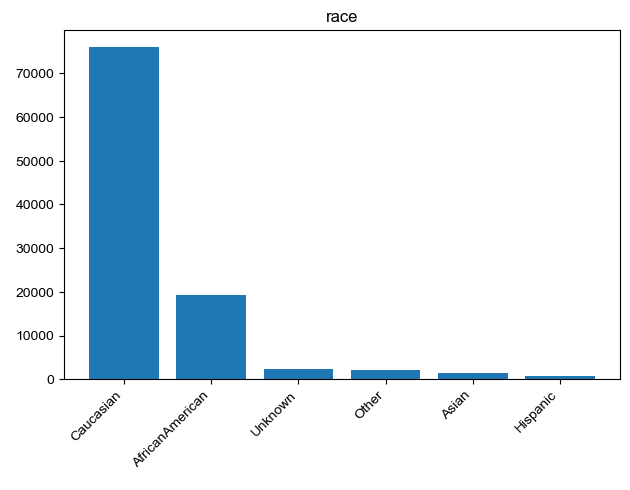

In [6]:
plt.bar(df['race'].unique(), df['race'].value_counts())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title('race')
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()


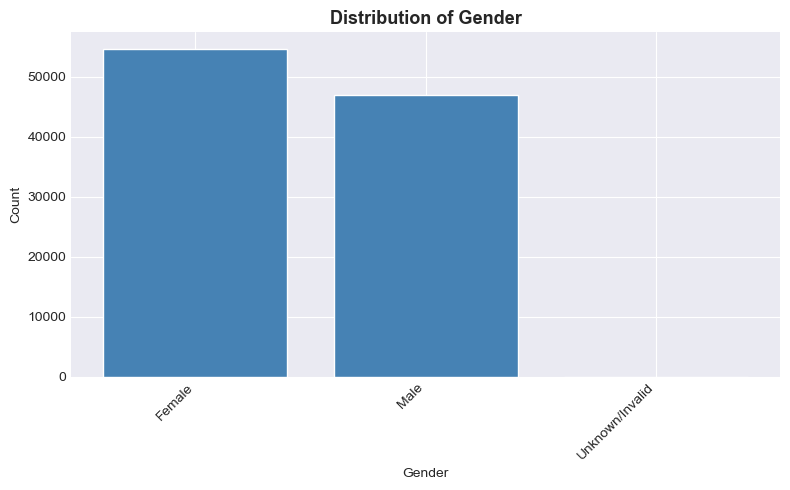

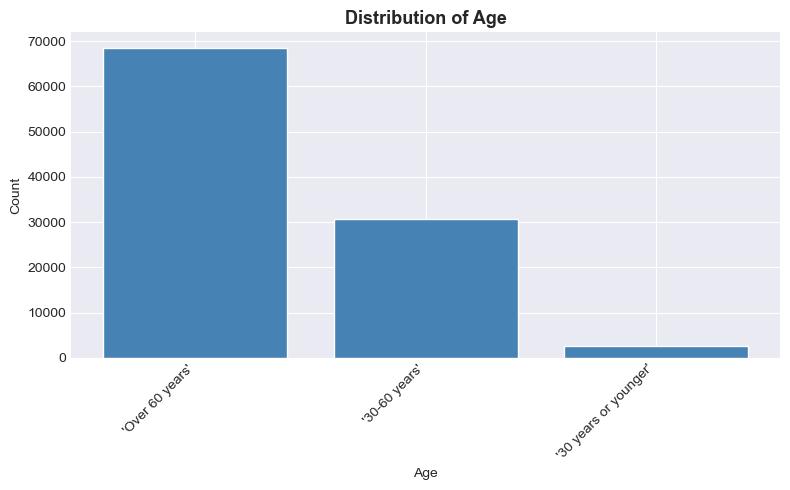

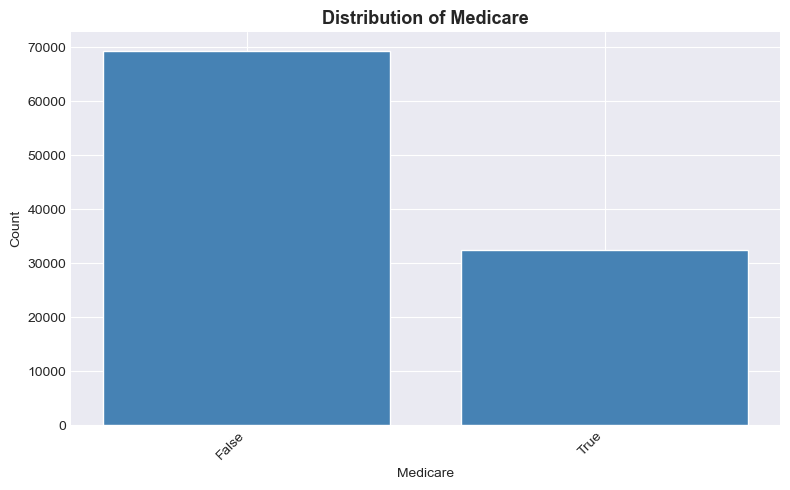

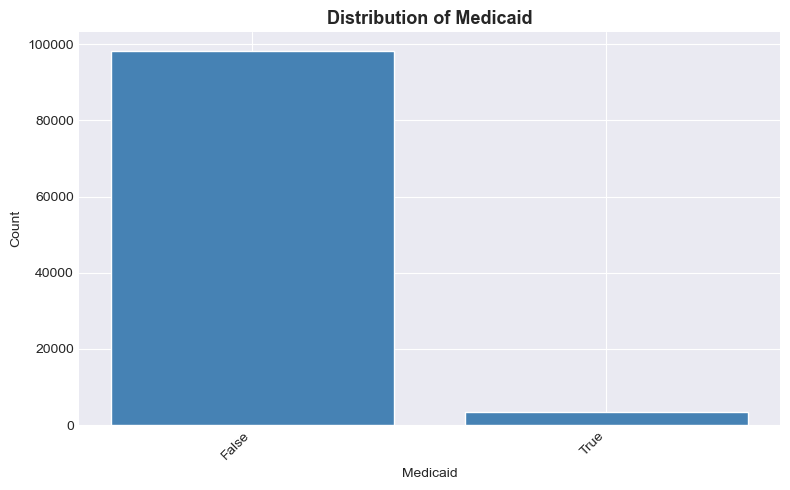

In [7]:
features = ['gender', 'age', 'medicare', 'medicaid']

for feature in features:
    counts = df[feature].value_counts()
    x_labels = counts.index
    if feature in ['medicare', 'medicaid']:
        x_labels = counts.index.astype(str)
    plt.figure(figsize=(8, 5))
    plt.bar(x_labels, counts.values, color='steelblue', edgecolor='white')
    plt.title(f'Distribution of {feature.capitalize()}', fontsize=13, fontweight='bold')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


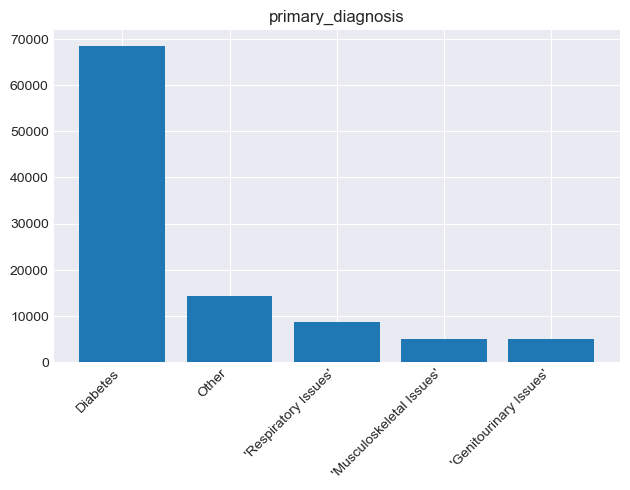

In [8]:


plt.bar(df['primary_diagnosis'].unique(), df['primary_diagnosis'].value_counts())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title('primary_diagnosis')
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()


### Quantitative Variables (Boxplots & Histograms Side-by-Side)
Here we visualize the distribution of each quantitative variable using side-by-side boxplots and histograms.

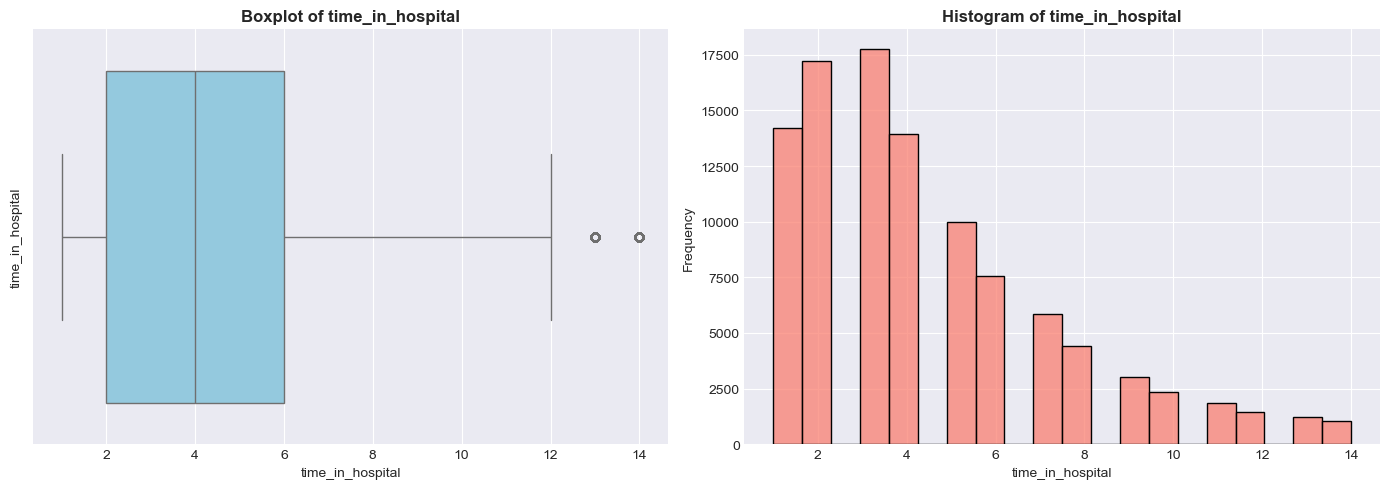

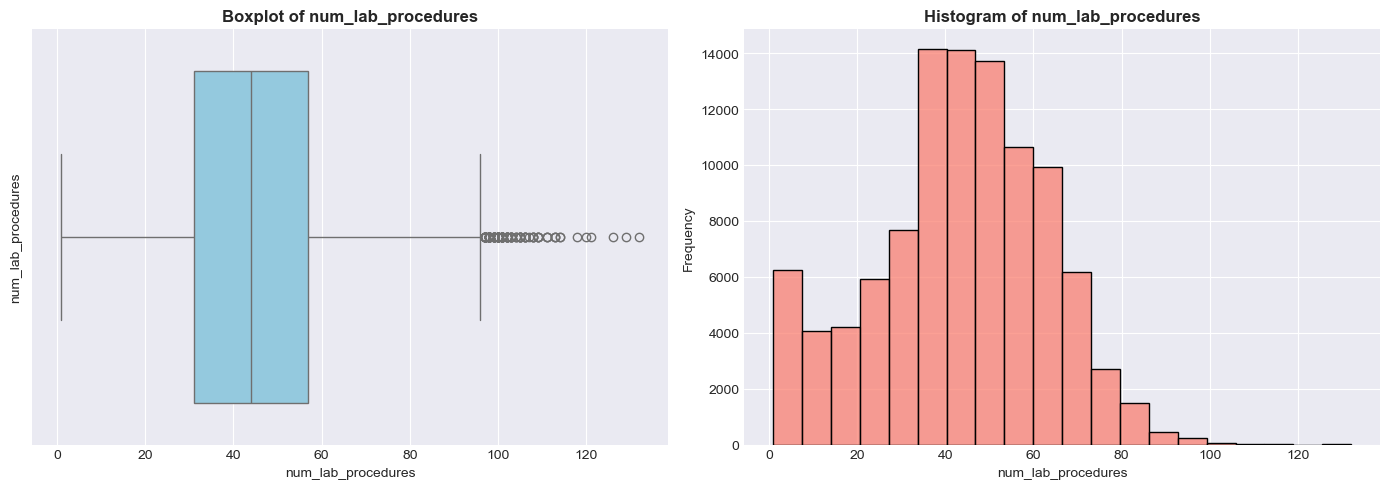

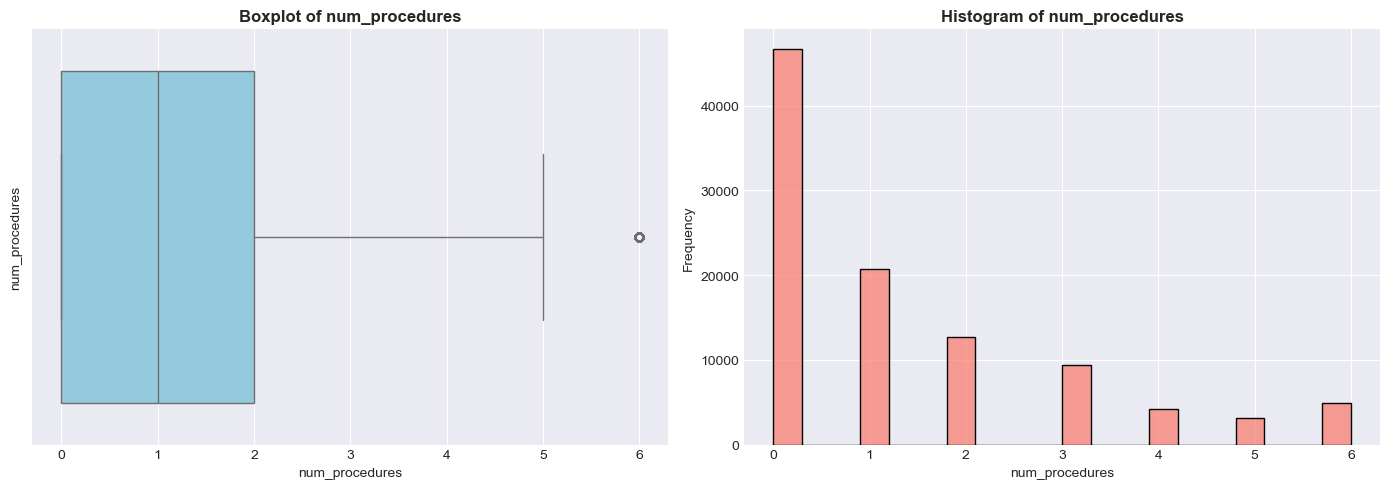

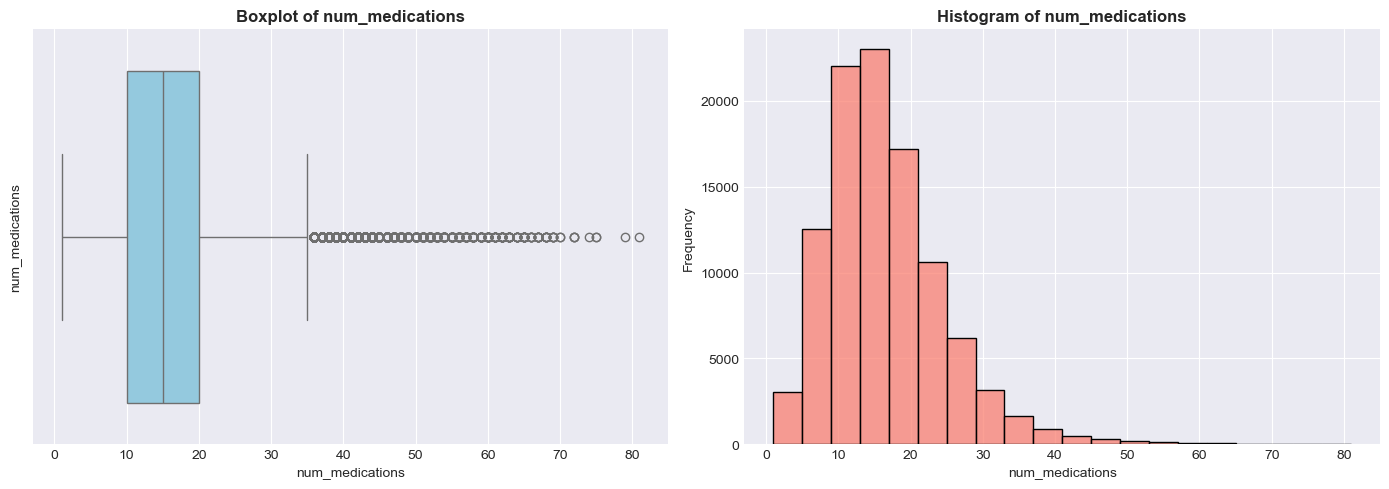

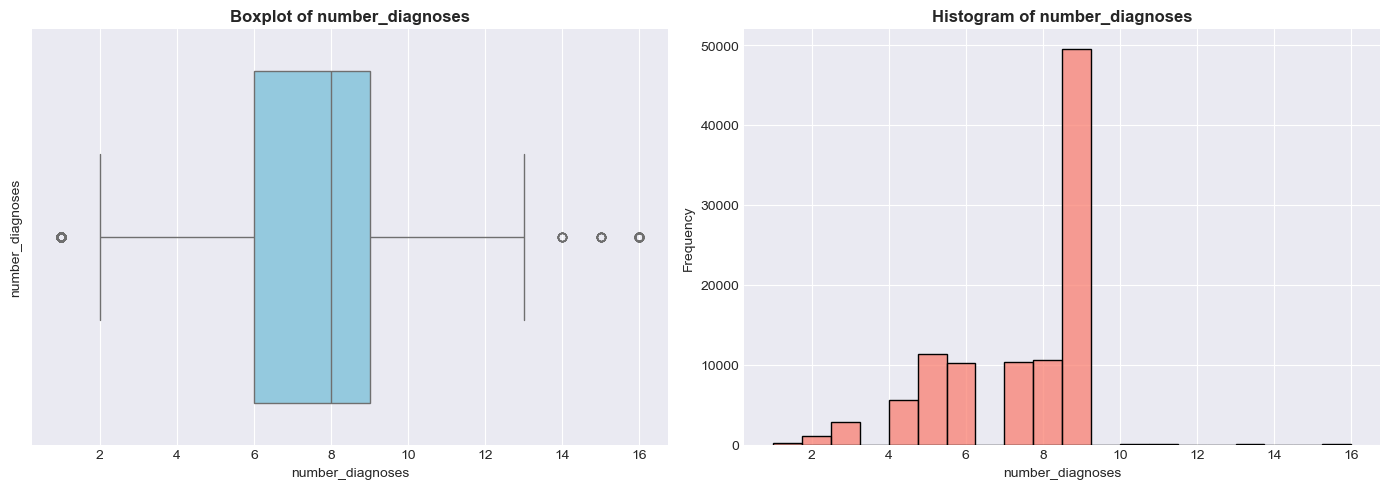

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

quant_vars = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']

for var in quant_vars:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot
    sns.boxplot(x=df[var], ax=axes[0], color='skyblue')
    axes[0].set_title(f'Boxplot of {var}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel(var)
    
    # Histogram
    sns.histplot(df[var], ax=axes[1], kde=False, color='salmon', bins=20)
    axes[1].set_title(f'Histogram of {var}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(var)
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

### Scatter Plot Matrix of Quantitative Variable Pairs
We render a scatter plot matrix for all pairs of quantitative variables. We sample a subset of 5,000 observations to render the pairplot efficiently.

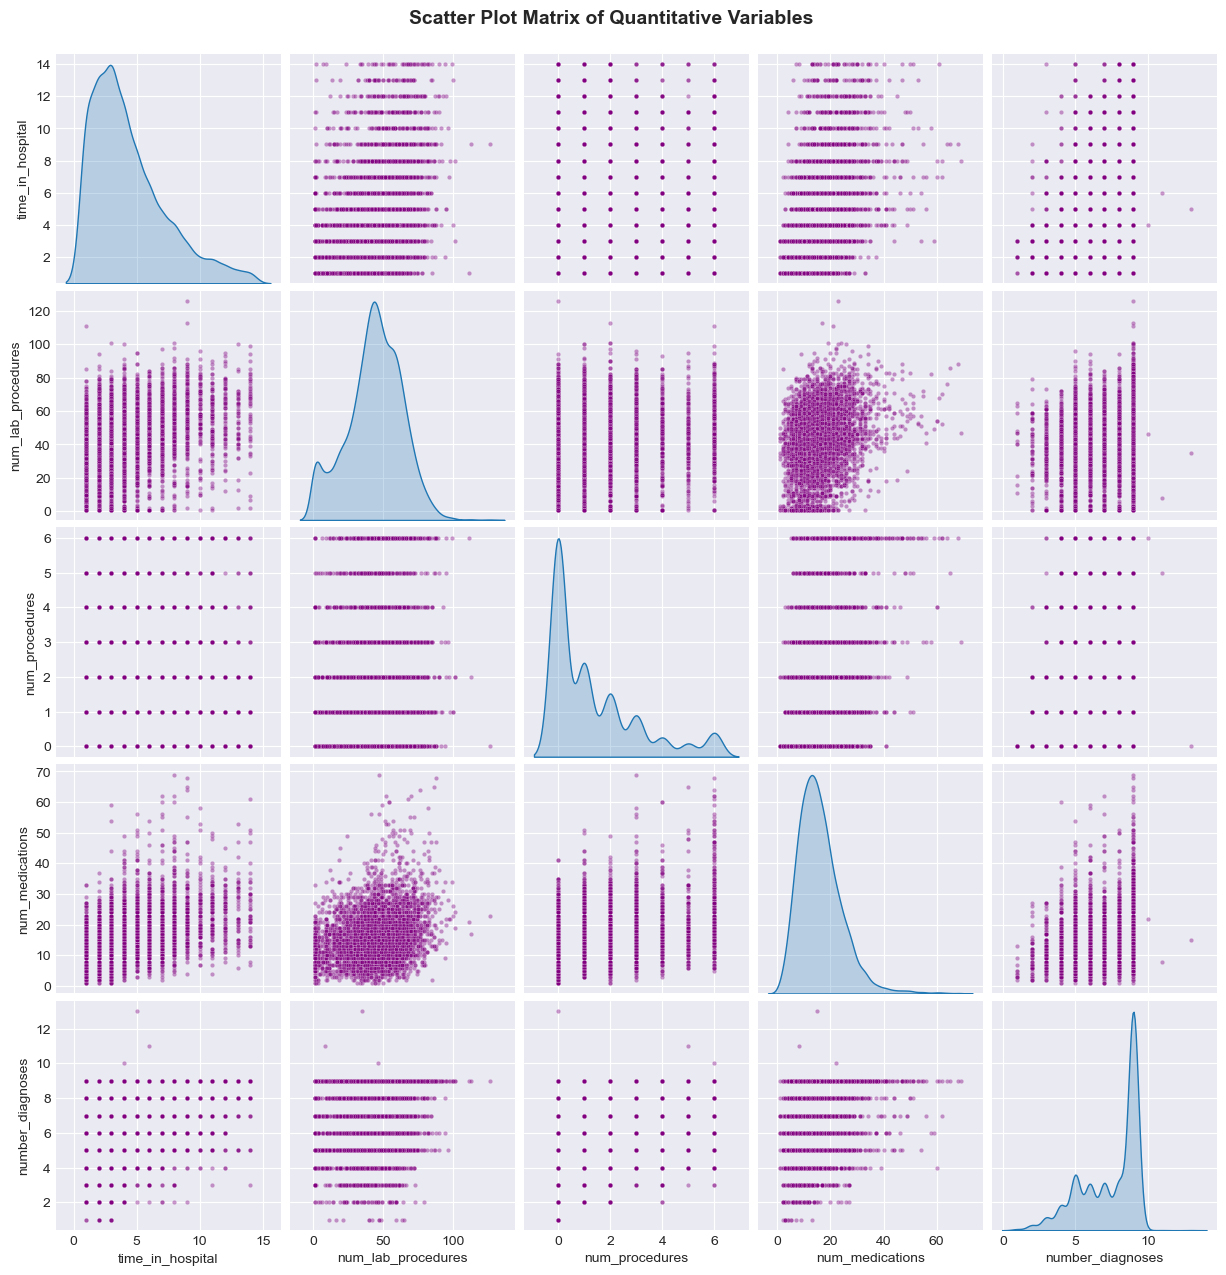

In [10]:
# Downsample to 5,000 points to render pairplot efficiently
sampled_df = df[quant_vars].sample(5000, random_state=42)

sns.pairplot(sampled_df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 10, 'color': 'purple'})
plt.suptitle('Scatter Plot Matrix of Quantitative Variables', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Base Rate Disparities in Sensitive Attributes
To support fairness auditing, we compute and visualize the 30-day hospital readmission rate across different subgroups for each sensitive attribute.

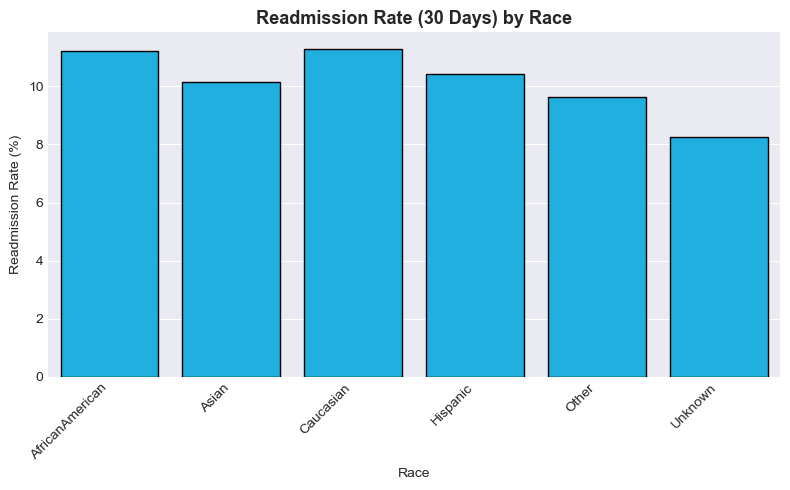

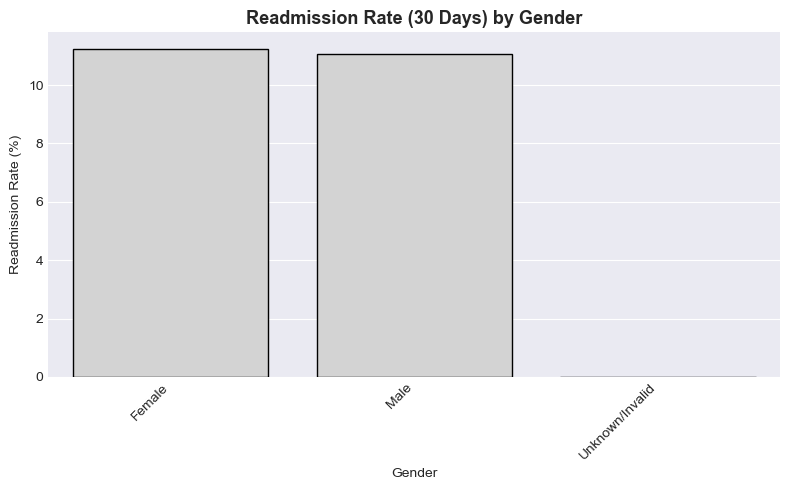

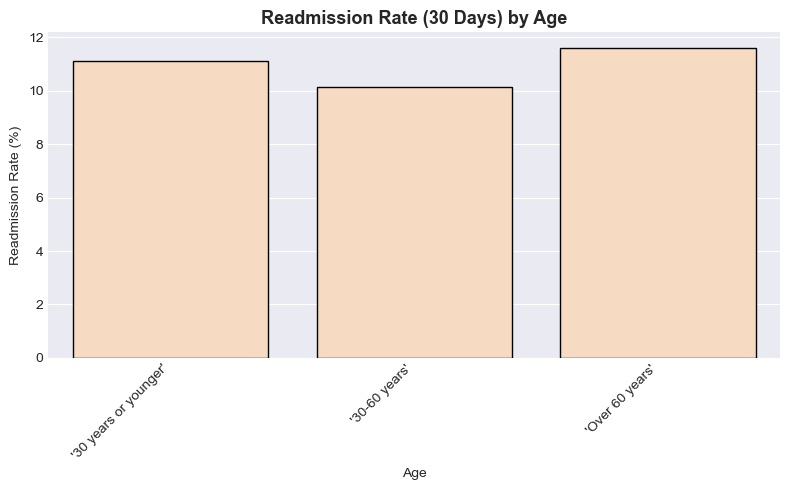

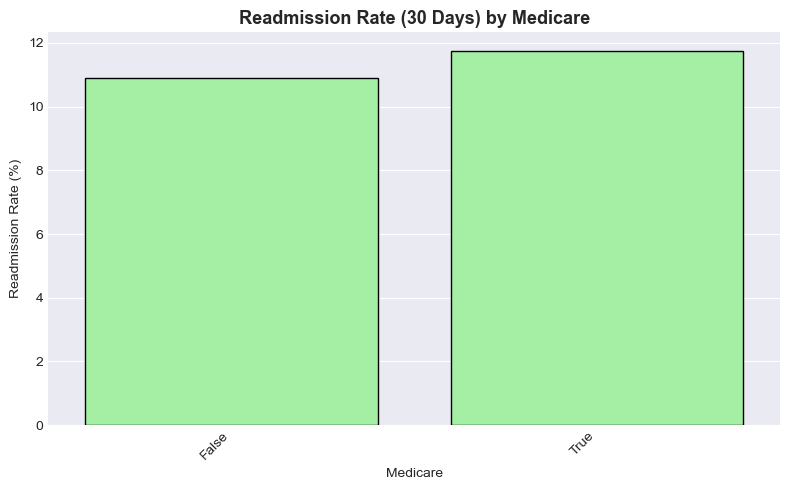

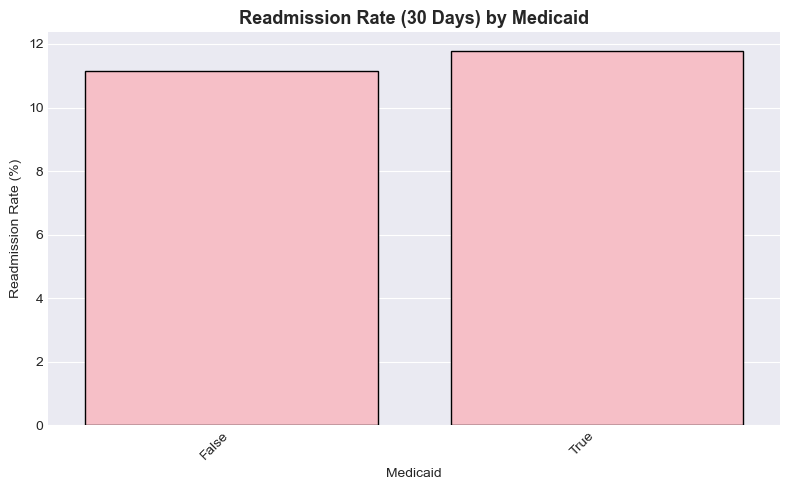

In [11]:
sensitive_attributes = ['race', 'gender', 'age', 'medicare', 'medicaid']
mycolors = ['deepskyblue','lightgrey','peachpuff','palegreen','lightpink']
t = 0

for attr in sensitive_attributes:
    # Cross-tabulate and calculate readmission rate in percentage
    # readmit_30_days is 1 if readmitted within 30 days, else 0
    ct = pd.crosstab(df[attr], df['readmit_30_days'], normalize='index') * 100
    
    plt.figure(figsize=(8, 5))
    # We display ct[1] which corresponds to readmit_30_days == 1
    sns.barplot(x=ct.index, y=ct[1], color=mycolors[t], edgecolor='black')
    plt.title(f'Readmission Rate (30 Days) by {attr.capitalize()}', fontsize=13, fontweight='bold')
    plt.xlabel(attr.capitalize())
    plt.ylabel('Readmission Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    t +=1